In [1]:
import requests
import json
import os
import pandas as pd
import urllib.request, urllib.error, urllib.parse
import pickle as pk
import networkx as nx
import random as rd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark import SparkConf
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import time
from collections import Counter
import seaborn as sns

In [2]:
#Let's import the unified gene annotations

with open('output/allsources_icd_gene_dict_unified.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

#Let's import the unified gene annotations lcc z-score
with open('output/allsources_icd_gene_dict_unified_lcczscore.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified_lcczscore = pk.load(handle)



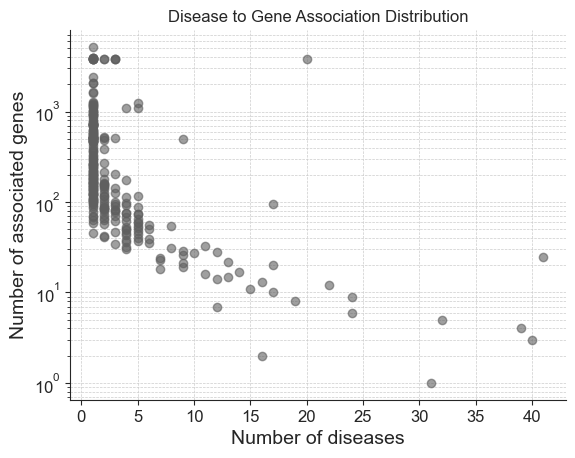

In [74]:
import matplotlib.pyplot as plt
from collections import Counter

# Step 1: Calculate the number of genes for each disease.
# This gives us the distribution of genes for each disease.
disease_gene_counts = [len(genelist) for genelist in allsources_icd_gene_dict_unified.values()]

# Step 2: Count how many diseases have the same number of associated genes.
gene_count_distribution = Counter(disease_gene_counts)

# Step 3: Prepare data for the plot.
# x-axis will be the number of diseases, y-axis will be the count of related genes.
x_values = list(gene_count_distribution.values())  # Number of diseases
y_values = list(gene_count_distribution.keys())    # Number of genes associated with those diseases

# Sorting data for better visualization
sorted_indices = sorted(range(len(x_values)), key=lambda k: x_values[k])
x_values = [x_values[i] for i in sorted_indices]
y_values = [y_values[i] for i in sorted_indices]

# Step 4: Plotting
fig, ax = plt.subplots()
ax.scatter(x_values, y_values, c='#5F5F5F', alpha=0.6)

#plt.xscale('log')  # Log scale if data distribution is wide
plt.yscale('log')
plt.xlabel('Number of diseases', fontsize=14)
plt.ylabel('Number of associated genes', fontsize=14)
plt.title('Disease to Gene Association Distribution')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Optionally enhance readability with grid lines
ax.grid(True, which="both", ls="--", linewidth=0.5)

# Simplify plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
plt.close()

In [16]:
#Let's plot the disease-geneset size distribution

tot_genelist_len=[]
for dis,genelist in allsources_icd_gene_dict_unified.items():
    tot_genelist_len.append(len(genelist))

tot_genelist_len_counter = Counter(tot_genelist_len)
tot_genelist_len_counter_x = list(tot_genelist_len_counter.keys())
tot_genelist_len_counter_y = list(tot_genelist_len_counter.values())

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_73387/181383174.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


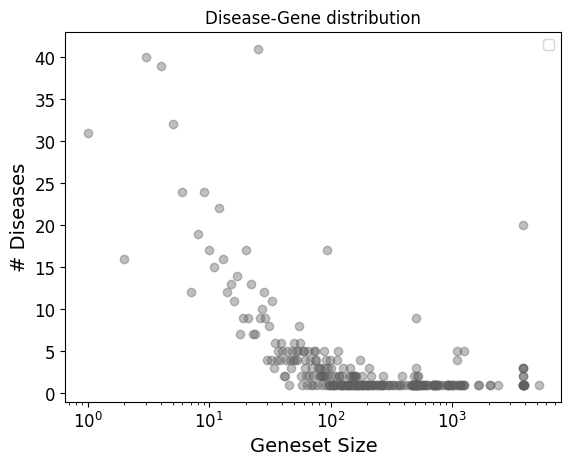

In [17]:
#Here, we compare the distribution of the total (raw) exposures/perturbed genes and the backboning

plt.scatter(tot_genelist_len_counter_x, tot_genelist_len_counter_y, c='#5F5F5F', alpha=0.4)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Geneset Size', fontsize=14)
plt.ylabel('# Diseases', fontsize=14)
plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)
plt.title('Disease-Gene distribution')
plt.legend()
plt.savefig('Figures/Fig1B.pdf',format='pdf',dpi=300, bbox_inches = "tight")  #This is now Fig1C
plt.show()

In [77]:
sum(tot_genelist_len_counter_y)

1023

In [23]:
np.median(tot_genelist_len)

31.0

In [5]:

# Sort the dictionary based on the length of the sets in descending order
sorted_allsources_icd_gene_dict_unified= sorted(allsources_icd_gene_dict_unified.items(), key=lambda item: len(item[1]), reverse=True)

# Extract the top 10 keys
top_10_keys = [key for key, value in sorted_allsources_icd_gene_dict_unified[:10]]

In [9]:
top_10_keys

['K51', 'A89', 'K21', 'J44', 'O43', 'M01', 'B94', 'G21', 'T86', 'H81']

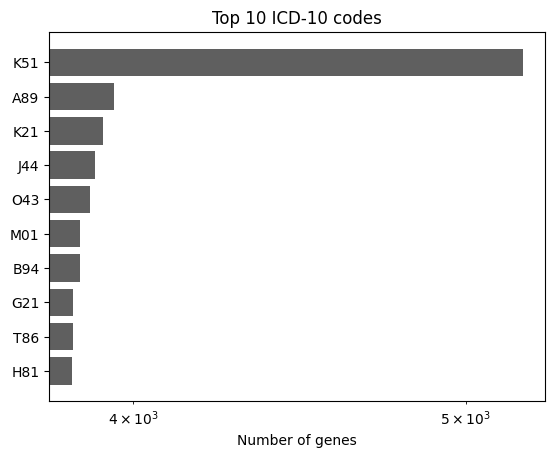

In [41]:
genelist_len = [len(allsources_icd_gene_dict_unified[dis]) for dis in top_10_keys] 

fig, ax = plt.subplots()

y_pos = np.arange(len(top_10_keys))

ax.barh(y_pos, genelist_len, align='center', color='#5F5F5F')
ax.set_yticks(y_pos, labels=top_10_keys)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xscale('log')
ax.set_xlabel('Number of genes')
ax.set_title('Top 10 ICD-10 codes')

plt.savefig('Figures/SF1D_TopICD10codes.pdf',format='pdf',dpi=300, bbox_inches = "tight") 
plt.savefig('Figures/SF1D_TopICD10codes.png',format='pdf',dpi=300, bbox_inches = "tight") 
plt.show()



In [43]:
for icd in allsources_icd_gene_dict_unified.keys():
    print(icd,len(allsources_icd_gene_dict_unified[icd]),round(allsources_icd_gene_dict_unified_lcczscore[icd],2))

K51 5195 4.41
A89 3950 10.87
K21 3920 10.33
J44 3900 10.25
O43 3885 10.22
M01 3859 10.36
B94 3859 10.04
G21 3843 10.54
T86 3841 10.73
H81 3839 10.72


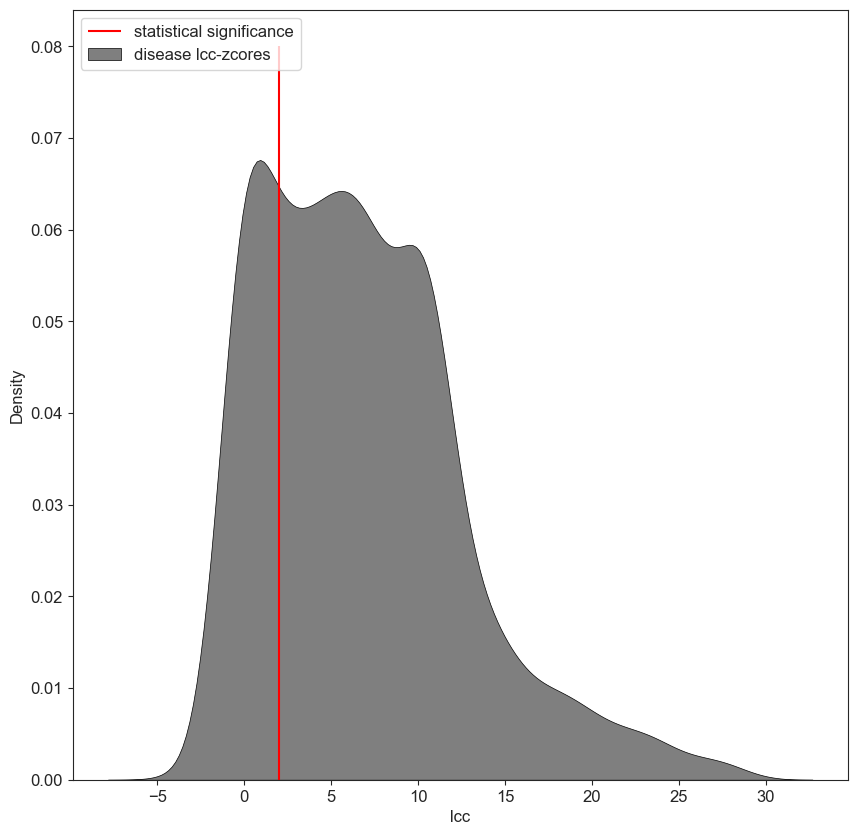

In [79]:
#Let's plot the distribution of all lcc z-scores

lcc_zscores = [i for i in allsources_icd_gene_dict_unified_lcczscore.values() if str(i)!='nan']
# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
plt.vlines(2,ymin=0,ymax=0.08,color='r',label='statistical significance')
sns.kdeplot(lcc_zscores,color='k',lw=.5,alpha=.5,fill=True,label='disease lcc-zcores')
plt.legend(loc='upper left',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('lcc',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Figures/Fig1C.pdf',format='pdf',dpi=300, bbox_inches = "tight")


In [43]:
len([i for i in lcc_zscores if i>2])

723

In [42]:
len(allsources_icd_gene_dict_unified_lcczscore)

1023

In [48]:
max(lcc_zscores)

28.284360079832595

In [50]:
for k,v in allsources_icd_gene_dict_unified_lcczscore.items():
    try:
        if v>27:
            print(k,v)
    except:
        pass

C65 27.37386705501572
D61 27.722262220929604
L74 28.284360079832595
C57 27.379908632117086


In [56]:
len(allsources_icd_gene_dict_unified['D61'])

47